# V49: Fee Control vs Static Markowitz (LQ45)

Notebook ini adalah pengembangan dari V48.
Tujuan: Membandingkan **V48 (AI + Fee Control)** dengan **Static Markowitz (No AI + Fee Control)**.

### Skenario Pengujian:
1.  **V48 (AI Smart)**: AI Regime Switch + Monthly Rebalancing + Buffer 5%.
2.  **Markowitz Static**: Tanpa AI (Always Invested) + Monthly Rebalancing + Buffer 5%.
    *   Tujuannya untuk melihat apakah AI (Regime Switching) memberikan nilai tambah dibandingkan sekadar strategi Markowitz tradisional yang sudah dihemat biayanya.
3.  **Benchmark**: IHSG/Market.

### Parameter Fee Control:
*   **Rebalancing Period**: 20 Hari (Bulanan).
*   **Turnover Buffer**: 0.05 (5%).
*   **Transaction Fee**: 0.25%.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (SMA Crossover Target) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic (Functions) ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_with_fee_control(test_dates, returns, ai_probs, threshold, 
                                    fee=0.0025, g_lookback=60, 
                                    rebal_period=20,
                                    turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {} 
    
    risk_status = False
    buffer = 0.05
    days_since_rebal = 999
    
    for i, date in enumerate(test_dates[:-1]):
        # --- 1. Regime Detection ---
        # If threshold is -1 (Static Mode), always Risk On
        if threshold < 0:
            prob = 1.0 
            risk_status = True 
            regime_changed = False # Never changes in static mode (effectively)
        else:
            prob = ai_probs.loc[date]
            prev_risk_status = risk_status
            
            if not risk_status and prob > (threshold + buffer): risk_status = True
            elif risk_status and prob < (threshold - buffer): risk_status = False
            
            regime_changed = (risk_status != prev_risk_status)
        
        # --- 2. Decide Target Weights ---
        target_weights = current_weights.copy()
        
        if not risk_status:
            # BEAR -> CASH
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # BULL -> EQUITY
            # Check Rebalance Trigger
            is_time_to_rebal = (days_since_rebal >= rebal_period)
            
            # Special case for Static: First day needs rebal
            if i == 0: is_time_to_rebal = True
            
            if regime_changed or is_time_to_rebal:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                # Check Turnover
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if i==0 or regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # --- 3. Execute & Fees ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        cost = val * turnover_actual * fee
        val -= cost
        
        # --- 4. Returns & Drift ---
        next_date = test_dates[i+1]
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            current_weights = {'CASH': 1.0}
        else:
            day_ret = 0
            new_weights_drifted = {}
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    day_ret += w * r
                    new_weights_drifted[asset] = w * (1 + r)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                current_weights = {k: v/total_w for k, v in new_weights_drifted.items()}
            else:
                current_weights = target_weights
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

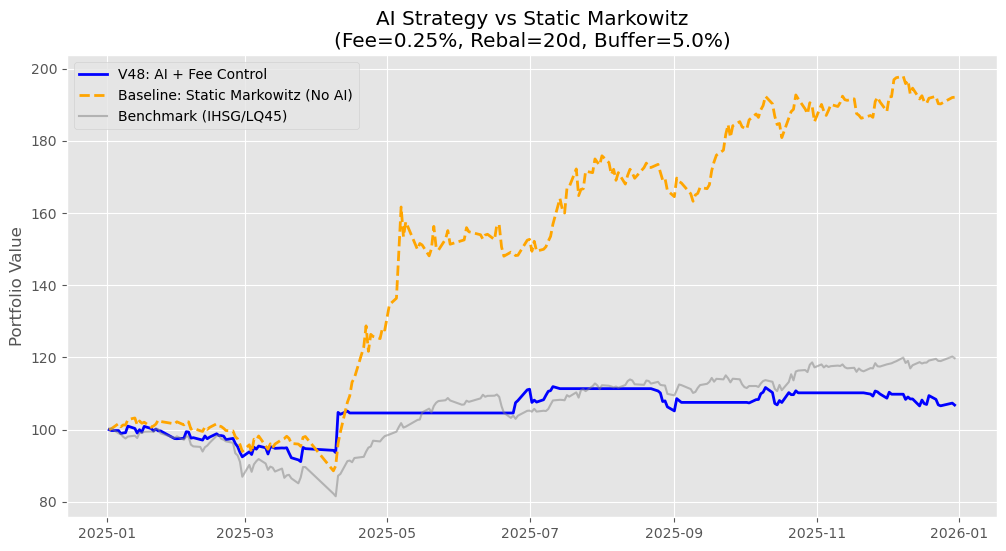

Final Portfolio Values:
V48 (AI Smart):       106.81
Static Markowitz:     192.06
Benchmark:            119.78
------------------------------
AI Value Added:       -85.25 points


In [4]:
# --- 4. Simulation & Comparison ---
test_dates = X_test.index

# Parameters
FEE = 0.0025
PERIOD = 20
BUFFER = 0.05

# 1. V48: AI Smart Control
res_ai_smart = run_simulation_with_fee_control(test_dates, returns, test_probs, opt_t, 
                                               fee=FEE, rebal_period=PERIOD, turnover_buffer=BUFFER)

# 2. Baseline: Static Markowitz (No AI, same Fee Control)
# We pass threshold = -1.0 to force "Risk On" always (ignoring AI)
res_static_markowitz = run_simulation_with_fee_control(test_dates, returns, test_probs, -1.0, 
                                                       fee=FEE, rebal_period=PERIOD, turnover_buffer=BUFFER)

# 3. Benchmark (Market)
benchmark = (1 + market_return.loc[test_dates]).cumprod() * 100

# --- Visualization ---
plt.figure(figsize=(12, 6))
plt.plot(res_ai_smart, label='V48: AI + Fee Control', color='blue', linewidth=2)
plt.plot(res_static_markowitz, label='Baseline: Static Markowitz (No AI)', color='orange', linestyle='--', linewidth=2)
plt.plot(benchmark, label='Benchmark (IHSG/LQ45)', color='gray', alpha=0.5)

plt.title(f'AI Strategy vs Static Markowitz\n(Fee={FEE*100}%, Rebal={PERIOD}d, Buffer={BUFFER*100}%)')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

print("Final Portfolio Values:")
print(f"V48 (AI Smart):       {res_ai_smart.iloc[-1].item():.2f}")
print(f"Static Markowitz:     {res_static_markowitz.iloc[-1].item():.2f}")
print(f"Benchmark:            {benchmark.iloc[-1]:.2f}")
print("-" * 30)
diff = res_ai_smart.iloc[-1].item() - res_static_markowitz.iloc[-1].item()
print(f"AI Value Added:       {diff:+.2f} points")